FOWT Farm Overview

Currently, the NREL 5MW wind turbine can be modeled on the OC3 Spar Type floating platform. Wind Speed, Wind Direction, Wave Speed, and Wave direction can all be used through the FOWT_spar_lookupto calculate the 6-dof through the FOWT_spar_lookup module under fowt in the offshore system.

Openfast was used to populate a lookup table with many simulations with varying environmental conditions (wind speed, direction, wave speed, wave direction). Linear interpolation is used for environemental other than those that were simulated. Since  waves naturally cause the floating turbine to rock back and forth, the average position value of the turbine over ~30 seconds, after any displacements from windspeed are taken into account.

The water depth of the lookup table used below is 320 meters. The mooring radius is 853.87 m, and 3 mooring lines are positioned 120 degrees apart.

In [24]:
from wesl.optimizer.offshore_system.fowt.FOWT_spar_lookup import FOWT_Spar

fowt_example = FOWT_Spar()

print(fowt_example.solve_static_movement(wind_speed=12, wind_direction=60, wave_direction=20, wave_height=7))


(np.int64(330), 20, 7, 12)
(np.float64(-13.391980290770533), np.float64(-17.678962532957396), np.float64(-0.4618228989446398), np.float64(3.146253628507257))


The function uses the Pywake coordinate system. Directions use degrees, where 0 degrees is from the North to the South, negative along the y axis. Wind speed is m/s, and wave_height is significant wave height in meters.

The returned values are: X displacement, Y displacement, Z displacement, and turbine tilt. Displacements are all meters, while tilt is in degrees. The other 2 degrees of freedom can also be accessed, but they are not currently used in any analysis.

We can visualize how the wind turbine is displaced under different wind speeds and directions.

(np.int64(270), 0, 1, np.int64(4))
(np.int64(276), 0, 1, np.int64(4))
(np.int64(282), 0, 1, np.int64(4))
(np.int64(288), 0, 1, np.int64(4))
(np.int64(294), 0, 1, np.int64(4))
(np.int64(300), 0, 1, np.int64(4))
(np.int64(306), 0, 1, np.int64(4))
(np.int64(312), 0, 1, np.int64(4))
(np.int64(318), 0, 1, np.int64(4))
(np.int64(324), 0, 1, np.int64(4))
(np.int64(330), 0, 1, np.int64(4))
(np.int64(336), 0, 1, np.int64(4))
(np.int64(342), 0, 1, np.int64(4))
(np.int64(348), 0, 1, np.int64(4))
(np.int64(354), 0, 1, np.int64(4))
(np.int64(0), 0, 1, np.int64(4))
(np.int64(6), 0, 1, np.int64(4))
(np.int64(12), 0, 1, np.int64(4))
(np.int64(18), 0, 1, np.int64(4))
(np.int64(24), 0, 1, np.int64(4))
(np.int64(30), 0, 1, np.int64(4))
(np.int64(36), 0, 1, np.int64(4))
(np.int64(42), 0, 1, np.int64(4))
(np.int64(48), 0, 1, np.int64(4))
(np.int64(54), 0, 1, np.int64(4))
(np.int64(60), 0, 1, np.int64(4))
(np.int64(66), 0, 1, np.int64(4))
(np.int64(72), 0, 1, np.int64(4))
(np.int64(78), 0, 1, np.int64(4))
(

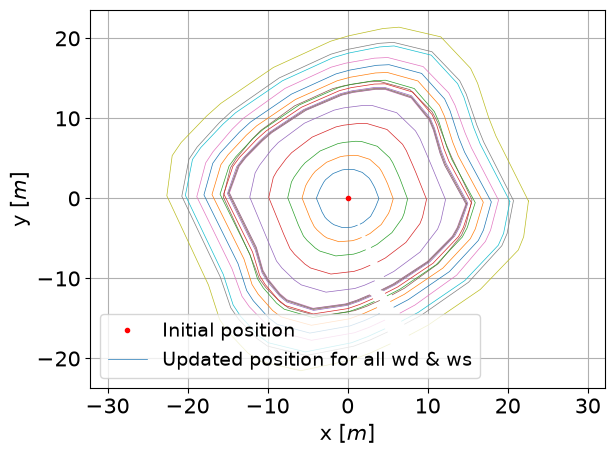

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

wind_speeds = np.linspace(4, 22, 18, endpoint=False, dtype = int)
wind_directions = np.linspace(0, 360, 60, endpoint=False, dtype = int)

displaced_x = np.zeros((len(wind_speeds), len(wind_directions)))
displaced_y = np.zeros((len(wind_speeds), len(wind_directions)))

for ws_index in range(len(wind_speeds)):
    for wd_index in range(len(wind_directions)):
        # print(wind_speeds[ws_index], wind_directions[wd_index])
        x_new, y_new, z_new, tilt_new = fowt_example.solve_static_movement(wind_speeds[ws_index],wind_directions[wd_index], wave_direction=0, wave_height=1)
        displaced_x[ws_index, wd_index] = x_new
        displaced_y[ws_index, wd_index] = y_new

# plot the displacements

plt.figure()
plt.plot([0], [0], 'r.')

# THIS NEEDS TO BE FIXED

for ws_index in range(len(wind_speeds)):
        x, y = displaced_x[ws_index,:], displaced_y[ws_index,:]
        # xr = np.vstack((xr, fowt_x[wt_index,0,ws_index]))
        # yr = np.vstack((yr, fowt_y[wt_index,0,ws_index]))
        color = ws_index / len(wind_speeds)# +0.1
        plt.plot(x, y,linewidth=0.5)

plt.rcParams.update({'font.size': 15})
plt.xlabel('x [$m$]')
plt.ylabel('y [$m$]')
plt.legend(['Initial position','Updated position for all wd & ws'],loc='best',prop={'size': 14})
plt.tight_layout()
plt.axis('equal')
plt.grid(True)
